# Statistical Hypothesis Testing on Marketing Segments
### MSBA Portfolio Project — Google Analytics Sample Dataset

**Objective:** Determine whether the observed differences in conversion rate and revenue between
segments (traffic medium, device category) are statistically significant or due to random variation.

**Important note:** The queries have been filtered to show data from just one sample month (July 1 to August 1, 2017). This holds seasonality constant across comparisions while allowing for a large enough sample size for reliable hypothesis testing.

**Data source:** Aggregated query results exported from BigQuery
(`bigquery-public-data.google_analytics_sample`), see `Final_GA_Portfolio_Queries.sql` for the exact SQL used to produce the CSVs loaded below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


Matplotlib is building the font cache; this may take a moment.


In [2]:
base_url = 'https://raw.githubusercontent.com/lcs-alt-gh/GA_Portfolio_Project/refs/heads/main/data/'

channel_df        = pd.read_csv(base_url + 'channel_conversion.csv')
paid_vs_unpaid_df = pd.read_csv(base_url + 'paid_vs_unpaid_conversion.csv')
device_df         = pd.read_csv(base_url + 'device_conversion.csv')
revenue_df        = pd.read_csv(base_url + 'device_revenue_stats.csv')
funnel_device_df  = pd.read_csv(base_url + 'funnel_by_device.csv')

print(channel_df)
print()
print(paid_vs_unpaid_df)
print()
print(device_df)
print()
print(revenue_df)

     segment  sessions  conversions
0    organic     36345          296
1     (none)     22024          695
2   referral     11349           15
3        cpc      2006           45
4  affiliate      1840            4
5        cpm       702           19
6    unknown         1            0

  segment  sessions  conversions
0  unpaid     69714         1006
1    paid      2708           64

  device_type  sessions  conversions
0     desktop     47266          967
1      mobile     23805           94
2      tablet      3192           13

  device_type  n_sessions  mean_revenue_usd  stddev_revenue_usd
0     desktop         967          130.2882            431.5421
1      mobile          94           67.2488            150.8563
2      tablet          13           38.0115             40.0736


## 2. Two-Proportion Z-Tests: Conversion Rate by Traffic Source



**2a.** Overall, does paid traffic convert differently than unpaid traffic?
**2b.** Within that, does the biggest paid channel (`cpc`- cost per click) convert differently than the biggest
unpaid channel (`organic`)?



### 2a. Paid vs. Unpaid (aggregate)

**Segment definitions used in the SQL:**
- **Paid:** `cpc` AKA paid search ads, `cpm` AKA paid display/banner ads
- **Unpaid:** `organic`, `referral`, `(none)`
- **Excluded:** `affiliate` (this segment has a ambiguous cost structure — commission-based, not pay-per-click/impression),
  `(not set)` (undetermined, not a defined channel)

**Hypotheses:**
- H0: The true conversion rates for paid and unpaid traffic are equal.
- H1: The true conversion rates for paid and unpaid traffic are not equal.

**Test:** Two-proportion z-test, alpha = 0.05.


In [3]:
row_paid   = paid_vs_unpaid_df.loc[paid_vs_unpaid_df['segment'] == 'paid'].iloc[0]
row_unpaid = paid_vs_unpaid_df.loc[paid_vs_unpaid_df['segment'] == 'unpaid'].iloc[0]

successes = np.array([row_paid['conversions'], row_unpaid['conversions']])
trials    = np.array([row_paid['sessions'],    row_unpaid['sessions']])

rate_paid   = row_paid['conversions']   / row_paid['sessions']
rate_unpaid = row_unpaid['conversions'] / row_unpaid['sessions']

z_stat, p_value = proportions_ztest(successes, trials)

print(f"Paid:   {row_paid['conversions']} / {row_paid['sessions']} sessions = {rate_paid:.4%} conversion")
print(f"Unpaid: {row_unpaid['conversions']} / {row_unpaid['sessions']} sessions = {rate_unpaid:.4%} conversion")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"Result: {'Statistically significant (reject H0)' if p_value < 0.05 else 'Not statistically significant (fail to reject H0)'} at alpha = 0.05")


Paid:   64 / 2708 sessions = 2.3634% conversion
Unpaid: 1006 / 69714 sessions = 1.4430% conversion

Z-statistic: 3.8946
P-value:     0.000098
Result: Statistically significant (reject H0) at alpha = 0.05


**Interpretation:** Paid traffic converts at a rate of about 1.6 times greater than unpaid traffic. The p-value is very small, indicating that these results are statistically significant and the gap between these groups is not likely a result of noise. This suggests that paid channels are more effective at driving purchases than unpaid channels.

It should also be noted that the paid traffic sample is much smaller than the unpaid sample (2,708 paid vs. 69,714 unpaid).


### 2b. Drill-down — Organic vs. CPC

The two largest individual channels, one from each bucket (paid and unpaid). This shows whether the
aggregate paid-vs-unpaid effect (if any) is being driven consistently, or whether it's really
just one channel doing the heavy lifting.

**Hypotheses:**
- H0: The true conversion rates for `organic` and `cpc` are equal.
- H1: The true conversion rates for `organic` and `cpc` are not equal.


In [4]:
medium_a = 'cpc'
medium_b = 'organic'

row_a = channel_df.loc[channel_df['segment'] == medium_a].iloc[0]
row_b = channel_df.loc[channel_df['segment'] == medium_b].iloc[0]

successes = np.array([row_a['conversions'], row_b['conversions']])
trials    = np.array([row_a['sessions'],    row_b['sessions']])

rate_a = row_a['conversions'] / row_a['sessions']
rate_b = row_b['conversions'] / row_b['sessions']

z_stat, p_value = proportions_ztest(successes, trials)

print(f"{medium_a}: {row_a['conversions']} / {row_a['sessions']} sessions = {rate_a:.4%} conversion")
print(f"{medium_b}: {row_b['conversions']} / {row_b['sessions']} sessions = {rate_b:.4%} conversion")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value: .2e}")
print(f"Result: {'Statistically significant (reject H0)' if p_value < 0.05 else 'Not statistically significant (fail to reject H0)'} at alpha = 0.05")


cpc: 45 / 2006 sessions = 2.2433% conversion
organic: 296 / 36345 sessions = 0.8144% conversion

Z-statistic: 6.6365
P-value:      3.21e-11
Result: Statistically significant (reject H0) at alpha = 0.05


**Interpretation:** Focusing on just the two largest channels shows an even sharper gap than in the previous test. The CPC segment conversion rate was nearly 3x higher than the organic search segment, which is notably higher than the 1.6x gap in the aggregate comparison in the previous test. The p-value shows these results are statistically significant. Like in the previous test, the samples have a similar imbalance (CPC with 2,006 sessions and organic with 36,345 sessions).

## 3. Chi-Square Test of Independence: Device Category vs. Conversion

**Question:** Is there an association between the device someone uses and whether they convert,
or are device category and conversion outcome independent of each other?

**Hypotheses:**
- H0: Device category and conversion outcome are independent.
- H1: Device category and conversion outcome are associated.

**Test:** Chi-square test of independence, alpha = 0.05.


In [5]:
device_df['non_conversions'] = device_df['sessions'] - device_df['conversions']
device_df['conversion_rate_pct'] = (device_df['conversions'] / device_df['sessions'] * 100).round(2)

contingency_table = device_df[['conversions', 'non_conversions']].values
print("Contingency table (rows = device categories, columns = [converted, did not convert, conversion rate]):")
print(device_df[['device_type', 'conversions', 'non_conversions', 'conversion_rate_pct']])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p_value:.6f}")
print(f"Result: {'Significant association (reject H0)' if p_value < 0.05 else 'No significant association (fail to reject H0)'} at alpha = 0.05")


Contingency table (rows = device categories, columns = [converted, did not convert, conversion rate]):
  device_type  conversions  non_conversions  conversion_rate_pct
0     desktop          967            46299               2.0500
1      mobile           94            23711               0.3900
2      tablet           13             3179               0.4100

Chi-square statistic: 328.0273
Degrees of freedom:   2
P-value:              0.000000
Result: Significant association (reject H0) at alpha = 0.05


**Interpretation:**
Device category and conversion are significantly associated based on the chi-square statistic and p-value. Desktop sessions convert at roughly 5x the rate of mobile or tablet (2.05% vs. 0.39%/0.41%), and observed desktop conversions substantially exceed what would be expected if device had no relationship to purchase behavior.

## 4. Confidence Interval: Average Order Value by Device

**Question:** Rather than reporting a single average revenue per order figure per device
(which implies false precision), what's the plausible range for the true mean?

**Method:** 95% confidence interval using the t-distribution, built from each segment's
mean, standard deviation, and sample size (aggregated in the SQL query).


In [6]:
def confidence_interval(mean, std, n, confidence=0.95):
    se = std / np.sqrt(n)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    margin = t_crit * se
    return mean - margin, mean + margin

results = []
for _, row in revenue_df.iterrows():
    lower, upper = confidence_interval(row['mean_revenue_usd'], row['stddev_revenue_usd'], row['n_sessions'])
    results.append({
        'device_type': row['device_type'],
        'mean_revenue_usd': row['mean_revenue_usd'],
        'n_sessions': row['n_sessions'],
        'ci_lower_95': round(lower, 4),
        'ci_upper_95': round(upper, 4)
    })

ci_df = pd.DataFrame(results)
print(ci_df)


  device_type  mean_revenue_usd  n_sessions  ci_lower_95  ci_upper_95
0     desktop          130.2882         967     103.0548     157.5216
1      mobile           67.2488          94      36.3504      98.1472
2      tablet           38.0115          13      13.7953      62.2277


**Interpretation:**
Desktop's CI does not overlap with mobile's or tablet's (Desktop \$103.05 – \$157.52, Mobile \$36.35 – \$98.15, Tablet \$13.80 – \$62.23), suggesting desktop generates meaningfully higher value orders than either which is consistent with the earlier finding that desktop also converts at a much higher rate. The intervals for mobile and tablet overlap with each other, so no confident distinction can be drawn between those two groups.

Important Note: Session-level revenue is typically right-skewed, so these t-based intervals are best read as directional rather than exact. For a more rigorous analysis, a bootstrap CI would better handle that skew.



## 5. Funnel Drop-off by Device

**Question:** The chi-square test showed mobile converts far less often than desktop, but not
*where* in the buying process mobile visitors are lost. This breaks the funnel out by device to
find that point.


### Stage-by-stage drop-off rates

This shows each transition individually to shed light on where in the buying process customers are lost.  

In [7]:
stage_cols = ['device_type', 'view_to_cart_pct', 'cart_to_checkout_pct',
              'checkout_to_purchase_pct', 'overall_conversion_pct']
print(funnel_device_df[stage_cols].to_string(index=False))

device_type  view_to_cart_pct  cart_to_checkout_pct  checkout_to_purchase_pct  overall_conversion_pct
    desktop           47.2000               49.4000                   53.1000                 12.3800
     mobile           35.0000               31.1000                   30.8000                  3.3500
     tablet           36.3000               27.9000                   36.1000                  3.6600


### Visualizing the funnel by device


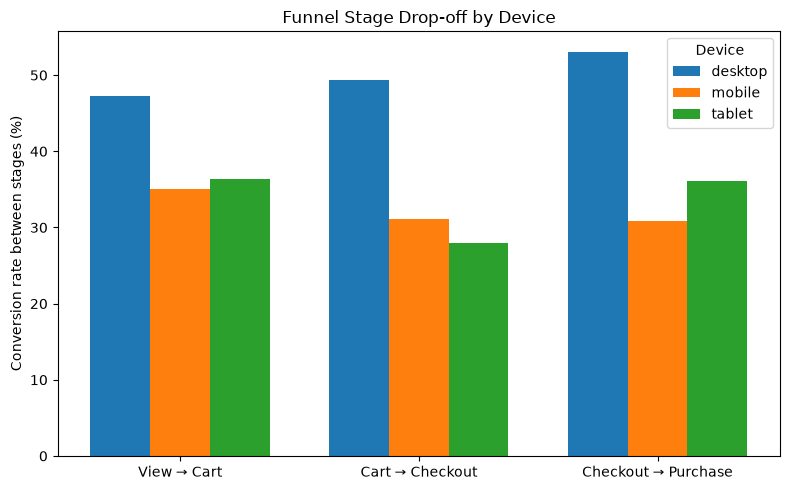

In [8]:


stages = ['view_to_cart_pct', 'cart_to_checkout_pct', 'checkout_to_purchase_pct']
stage_labels = ['View → Cart', 'Cart → Checkout', 'Checkout → Purchase']

x = np.arange(len(stages))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, (_, row) in enumerate(funnel_device_df.iterrows()):
    ax.bar(x + i * width, [row[s] for s in stages], width, label=row['device_type'])

ax.set_xticks(x + width)
ax.set_xticklabels(stage_labels)
ax.set_ylabel('Conversion rate between stages (%)')
ax.set_title('Funnel Stage Drop-off by Device')
ax.legend(title='Device')
plt.tight_layout()
plt.show()


**Interpretation:** The gap between desktop and portable device (both mobile and tablet), remain substantial at each stage, with mobile and tablet remaining close to each other. This suggests that screen size may be a factor in whether or not a customer ultimately completes their purchase. The next section investigates how much variation there is for each device type across the whole process (from viewing the product to completing the purchase) to deterimine how much these fluctuations actually matter. 


In [9]:
stage_cols = ['view_to_cart_pct', 'cart_to_checkout_pct', 'checkout_to_purchase_pct']

funnel_device_df['stage_mean'] = funnel_device_df[stage_cols].mean(axis=1)
funnel_device_df['stage_std'] = funnel_device_df[stage_cols].std(axis=1)  # sample std (ddof=1)
funnel_device_df['stage_range'] = funnel_device_df[stage_cols].max(axis=1) - funnel_device_df[stage_cols].min(axis=1)
funnel_device_df['stage_cv_pct'] = (funnel_device_df['stage_std'] / funnel_device_df['stage_mean'] * 100).round(2)

print(funnel_device_df[['device_type', 'stage_mean', 'stage_std', 'stage_range', 'stage_cv_pct']])

  device_type  stage_mean  stage_std  stage_range  stage_cv_pct
0     desktop     49.9000     2.9816       5.9000        5.9800
1      mobile     32.3000     2.3431       4.2000        7.2500
2      tablet     33.4333     4.7931       8.4000       14.3400


**Interpretation:** With only three stages per device, these are descriptive measures rather than a formal significance test, but they quantify what the chart above suggested. Mobile has the lowest standard deviation (2.34) and the smallest range (4.2 points) of the three segments — and while its coefficient of variation (7.25%) is a bit higher than desktop's (5.98%), both of these segments are far more stable than tablet's (14.34%). Tablet's higher variability is driven by its comparatively weak cart-to-checkout stage (27.9%, versus 36.3% in the previous stage and 36.1% in its final stage). This supports the earlier funnel finding: mobile's conversion issue looks like a consistently elevated drop-off across the whole buying process, rather than one specific broken step while tablet's funnel behaves less uniformly, with the final stage (checkout to purchase) standing out as the weak point.


## 6. Summary & Business Recommendation


**Channel**: Paid traffic converts at a significantly higher rate than unpaid overall (2.36% vs. 1.44%). The substantial gap between these two segments suggests that the unpaid rate is being propped up by the direct and referral traffic, not the organic searches. Because this only measures the conversion rate, a spend decision would also require acquisition cost data which is not included in this dataset.

**Device**: Desktop outperforms both mobile and tablet on conversion rate (2.05% vs. 0.39% and 0.41%) and on the average order ($130.29 vs. $67.25 for mobile and $38.01 for tablet, and non-overlapping CI for desktop vs. either segment). This means that the desktop segment is not only more likely to convert from viewer to buyer but also spend more per order. The funnel breakdown shows why conversion differs: the gap between desktop and mobile widens at every stage, peaking at the final stage (Checkout to Purchase). Tablet outperforms mobile at the same stage, suggesting there could be friction in the checkout to payment process for mobile users and not just general browsing issues. Mobile's drop-off is also the most consistent of the three segments stage-to-stage (CV of 7.25%, close to desktop's 5.98%), reinforcing that this is a broad, ongoing friction issue throughout the mobile buying process rather than one isolated failure point whereas tablet's higher variability (14.34%) points to a distinct, single weak stage instead.

**Recommendation**: Prioritize an audit of the full mobile checkout process. The previous results show that mobile drop-off rate holds fairly steady across all three funnel stages rather than spiking specifically at once staage. For tablet, it is worth investigating further the drop off at the final stage to see if there is friction in the customer experience when completign a purchase. When a customer is that close to making a purchase, it should be as easy as possible for them to complete the process. For channel strategy, get acquisition costs per medium to determine the ROI of paid and unpaid traffic. This dataset alone does not have enough information to make budget changes. 
